In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.gridspec as gridspec
from datetime import date

In [3]:
plt.style.use('/Users/lib278/Code/Python3/mpl_stylefiles/mystyle.mplstyle')

Bad value in file '/Users/lib278/Code/Python3/mpl_stylefiles/mystyle.mplstyle', line 17 ("mathtext.fallback: dejavsans  # Select fallback font from ['cm' (Computer Modern), 'stix'"): Key mathtext.fallback: dejavsans is not a valid fallback font name. Valid fallback font names are cm,stix,stixsans. Passing 'None' will turn fallback off.


In [4]:
today = date.today()
date_str = today.strftime("%Y-%b-%d")

master_obliquities_sheet_url = "https://docs.google.com/spreadsheets/d/12tK0oF65LOwOJwdk55i2hl6aX9Q7O5SxxDfihbpLrUI/edit#gid=0"
url_master_obliquities = master_obliquities_sheet_url.replace('/edit#gid=', '/export?format=csv&gid=')

df_master_obliquities_goog = pd.read_csv(url_master_obliquities)

df_master_obliquities_goog = df_master_obliquities_goog[df_master_obliquities_goog['ar'] > 0]
df_master_obliquities_goog = df_master_obliquities_goog[(df_master_obliquities_goog['clear_stellar_multiple'] != 'sb') & (df_master_obliquities_goog['clear_stellar_multiple'] != '1')]

cross_match = False
if cross_match == True:
    df_master_obliquities_goog = df_master_obliquities_goog[(df_master_obliquities_goog['mplanet'] >= 0.3) & (df_master_obliquities_goog['mplanet'] < 13.0)]
else:
    df_master_obliquities_goog = df_master_obliquities_goog[(df_master_obliquities_goog['mplanet'] >= 0.3)]

df_master_obliquities_goog = df_master_obliquities_goog[df_master_obliquities_goog['rplanet'] >= 0.7137]
df_master_obliquities = df_master_obliquities_goog[df_master_obliquities_goog['teff'] > 0]

hot_jupiters = df_master_obliquities_goog[df_master_obliquities_goog['ar'] < 20]
warm_jupiters = df_master_obliquities_goog[(df_master_obliquities_goog['ar'] >= 20)]  #  & (df_master_obliquities['ar'] < 500)]

hot_stars = df_master_obliquities_goog[df_master_obliquities_goog['teff'] >= 6200]
cool_stars = df_master_obliquities_goog[df_master_obliquities_goog['teff'] < 6200]


# for bep_i in range(len(hot_jupiters['teff'].values)):
#     print(hot_jupiters['name'].values[bep_i], type(hot_jupiters['teff'].values[bep_i]))


hot_jupiters_hot_stars = hot_jupiters[hot_jupiters['teff'] >= 6200]
hot_jupiters_cool_stars = hot_jupiters[hot_jupiters['teff'] < 6200]
warm_jupiters_hot_stars = warm_jupiters[warm_jupiters['teff'] >= 6200]
warm_jupiters_cool_stars = warm_jupiters[warm_jupiters['teff'] < 6200]

cross_match = False
if cross_match == True:
    hot_jupiters_hot_stars = hot_jupiters_hot_stars[hot_jupiters_hot_stars['istar/deltai'] > 0]
    hot_jupiters_cool_stars = hot_jupiters_cool_stars[hot_jupiters_cool_stars['istar/deltai'] > 0]
    warm_jupiters_hot_stars = warm_jupiters_hot_stars[warm_jupiters_hot_stars['istar/deltai'] > 0]
    warm_jupiters_cool_stars = warm_jupiters_cool_stars[warm_jupiters_cool_stars['istar/deltai'] > 0]

# df_hot_stars = df_master_obliquities[df_master_obliquities['teff'] >= 6200]
# df_cool_stars = df_master_obliquities[df_master_obliquities['teff'] < 6200]


# print(hot_jupiters_cool_stars[['name', 'mplanet']])
# print('\nlen: ', len(hot_jupiters_cool_stars))
print(warm_jupiters_cool_stars[['name', 'mplanet']])
print('\nlen: ', len(warm_jupiters_cool_stars))




            name  mplanet
1        AF Lepb    3.200
19     HAT-P-17b    0.530
52     HD 17156b    3.260
62     HD 80606b    4.110
68        K2-139    0.387
74       K2-287b    0.320
102   Kepler-30c    1.690
105  Kepler-420b    1.450
107   Kepler-447    1.370
114   Kepler-539    0.970
118    Kepler-75    9.900
119   Kepler-89d    0.330
132    TOI-1130c    0.970
133    TOI-1136d    8.000
146    TOI-2202b    0.900
153     TOI-3972    3.670
162     TOI-811b   59.900
230     WASP-59b    0.860
246     WASP-84b    0.690

len:  19


In [5]:
print(len(df_master_obliquities))
print(len(hot_jupiters))
print(len(warm_jupiters))

161
137
25


[6130. 8102. 6440. 5444. 6785. 6202. 5653. 6728. 5620. 6140. 5293. 4549.
 5695. 5885. 6329. 6290. 6338. 6269. 6460. 6442. 5620. 6448. 6820. 5981.
 6566. 7669. 6570. 6563. 6410. 6350. 5233. 6351. 7905. 5683. 6147. 6046.
 5050. 6117. 5546. 7204. 5394. 5654. 6154. 5695. 6302. 6131. 5948. 7338.
 6596. 8640. 6306. 6246. 6699. 9495. 7986. 5638. 5498. 5408. 5615. 6820.
 5820. 5206. 6182. 6213. 7687. 7687. 7800. 6450. 4820. 4645. 5052. 4250.
 5770. 6274. 5595. 6330. 5814. 5880. 6415. 6530. 5169. 5537. 5900. 5831.
 6800. 5420. 3937. 6560. 5972. 6460. 6295. 6643. 6026. 5789. 6261. 5261.
 5846. 6595. 6705. 6380. 6263. 6002. 6441. 6698. 6586. 6313. 5658. 6250.
 5914. 6459. 6326. 5630. 6900. 6334. 6550. 6300. 7946. 6443. 6400. 5460.
 5987. 6153. 6489. 5736. 5950. 6084. 6362. 6363. 6140. 7430. 6239. 6385.
 5546. 4286. 5576. 5540. 5400. 5000. 4754. 4650. 5770. 5926. 6267. 6230.
 6600. 5380. 5991. 6208. 5983. 6329. 6291. 6906. 6520. 4158. 5238. 5685.
 5618. 6987. 6304. 6720. 6250.]


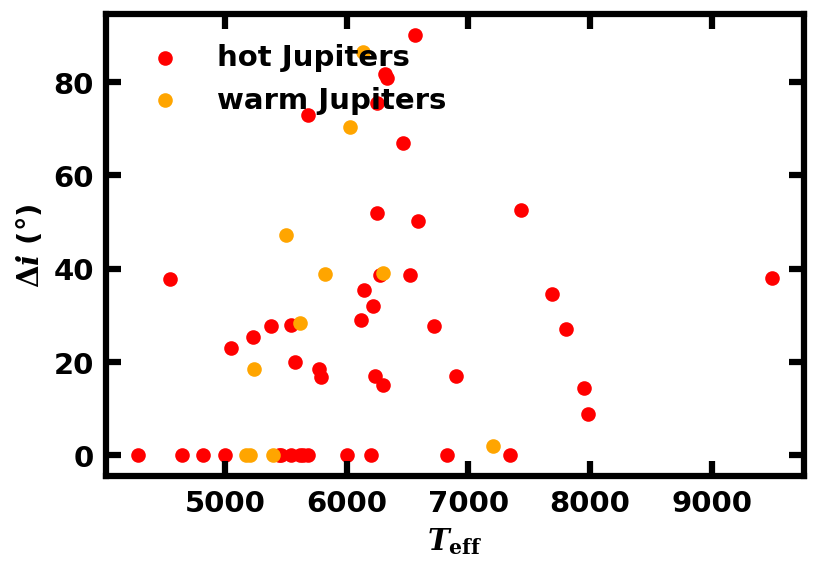

In [6]:
fig = plt.figure(figsize=(6, 4), dpi=150)
ax = plt.subplot(111)
ax.set_xlabel(r'$T_{\mathrm{eff}}$')

print(df_master_obliquities['teff'].values)


plot_istar = True
plot_lam = False
plot_psi = False

if plot_istar == True:
    plot_y1 = abs(90-np.array(hot_jupiters['istar/deltai'].values))
    plot_y2 = abs(90-np.array(warm_jupiters['istar/deltai'].values))
    ax.set_ylabel(r'$\Delta i$ ($\degree$)')
elif plot_lam == True:
    plot_y1 = abs(np.array(hot_jupiters['lam'].values))
    plot_y2 = abs(np.array(warm_jupiters['lam'].values))
    ax.set_ylabel(r'$\lambda$ ($\degree$)')
elif plot_psi == True:
    plot_y1 = abs(np.array(hot_jupiters['psi'].values))
    plot_y2 = abs(np.array(warm_jupiters['psi'].values))
    ax.set_ylabel(r'$\Psi$ ($\degree$)')

ax.scatter(hot_jupiters['teff'].values, plot_y1, color='red', label='hot Jupiters')
ax.scatter(warm_jupiters['teff'].values, plot_y2, color='orange', label='warm Jupiters')

ax.legend(loc='upper left')

plt.show()

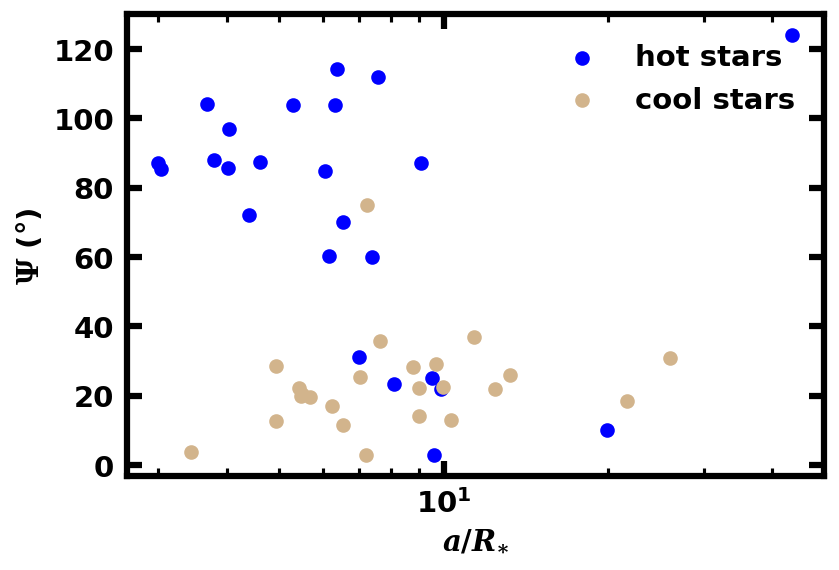

In [7]:
fig = plt.figure(figsize=(6, 4), dpi=150)
ax = plt.subplot(111)
ax.set_xlabel(r'$a/R_{\ast}$')


plot_istar = False # True
plot_lam = False # True
plot_psi = True

if plot_istar == True:
    plot_y1 = abs(90-np.array(hot_stars['istar/deltai'].values))
    plot_y2 = abs(90-np.array(cool_stars['istar/deltai'].values))
    ax.set_ylabel(r'$\Delta i$ ($\degree$)')
elif plot_lam == True:
    plot_y1 = abs(np.array(hot_stars['lam'].values))
    plot_y2 = abs(np.array(cool_stars['lam'].values))
    ax.set_ylabel(r'$\lambda$ ($\degree$)')
elif plot_psi == True:
    plot_y1 = abs(np.array(hot_stars['psi'].values))
    plot_y2 = abs(np.array(cool_stars['psi'].values))
    ax.set_ylabel(r'$\Psi$ ($\degree$)')

ax.scatter(hot_stars['ar'].values, plot_y1, color='blue', label='hot stars')
ax.scatter(cool_stars['ar'].values, plot_y2, color='tan', label='cool stars')

ax.set_xscale('log')

leg = ax.legend(loc='upper right')
leg.get_frame().set_linewidth(2.0)
leg.get_frame().set_edgecolor('#000000')

plt.show()

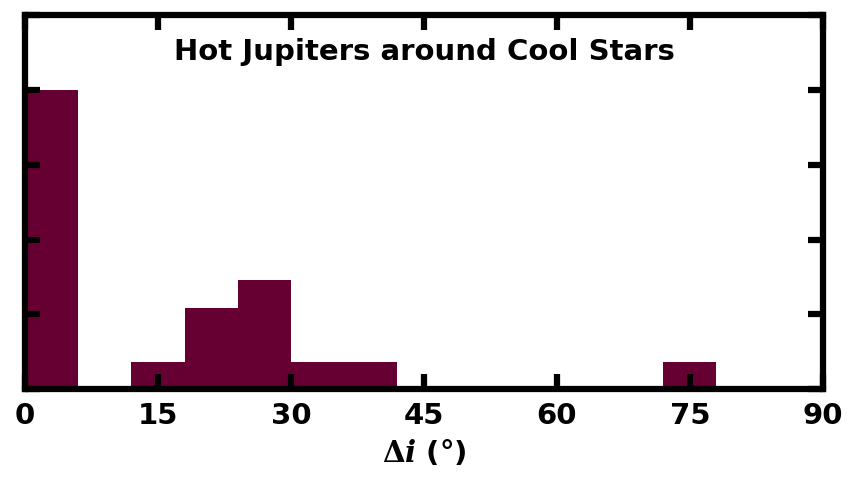

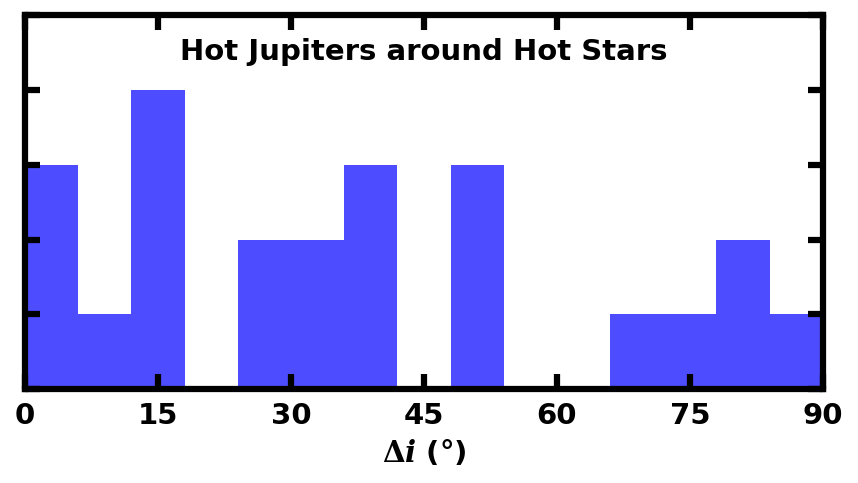

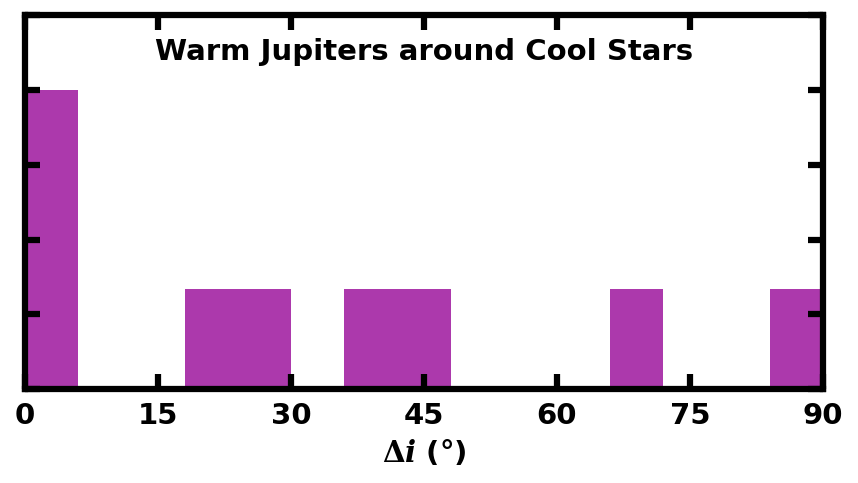

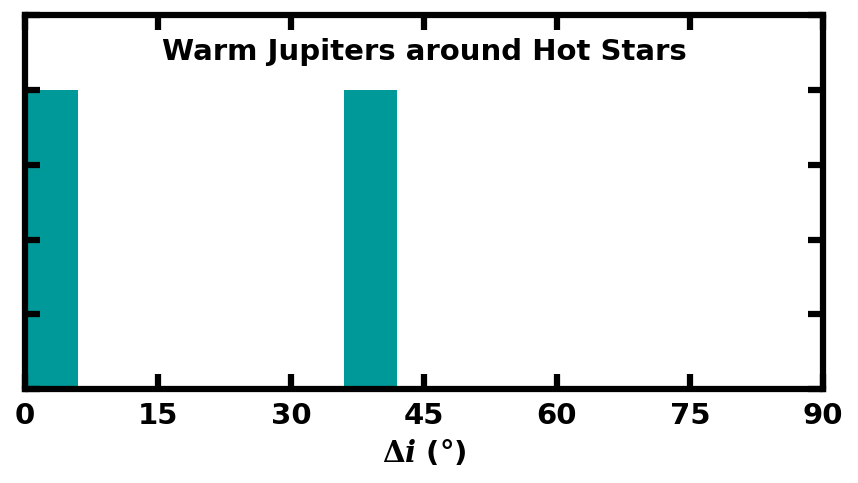

In [8]:



plot_istar = True  # False  # True  # False  #  True
plot_lam = False  # True  # False
plot_psi =  False  # True  # False  # True  # False

obliquity_list = [hot_jupiters_cool_stars, hot_jupiters_hot_stars, warm_jupiters_cool_stars, warm_jupiters_hot_stars]
obliquity_labs = ['Hot Jupiters around Cool Stars', 'Hot Jupiters around Hot Stars', 'Warm Jupiters around Cool Stars', 'Warm Jupiters around Hot Stars']
obliquity_colors = ['#660033', '#4d4dff', '#ac39ac', '#009999']


for bep in range(len(obliquity_list)):
    if plot_istar == True:
        xlab = r'$\Delta i$ ($\degree$)'
        bin_width = 6  # degrees
        hist_bins = np.arange(0, 90 + bin_width, bin_width)
        vals = abs(90-abs(np.array(obliquity_list[bep]['istar/deltai'].values)))
        xlim = [0, 90]
        ylim = [0, 22]
        savelab = 'deltai'
        xticks = [0, 15, 30, 45, 60, 75, 90]
    elif plot_lam == True:
        xlab = r'$\lambda$ ($\degree$)'
        bin_width = 15  # degrees
        hist_bins = np.arange(0, 180 + bin_width, bin_width)
        vals = abs(np.array(obliquity_list[bep]['lam'].values))
        xlim = [0, 180]
        ylim = [0, 44]
        savelab = 'lam'
        xticks = [0, 30, 60, 90, 120, 150, 180]
    elif plot_psi == True:
        xlab = r'$\Psi$ ($\degree$)'
        bin_width = 15  # degrees
        hist_bins = np.arange(0, 180 + bin_width, bin_width)
        vals = abs(np.array(obliquity_list[bep]['psi'].values))
        xlim = [0, 180]
        ylim = [0, 15]
        savelab = 'psi'
        xticks = [0, 30, 60, 90, 120, 150, 180]
    

    
    fig = plt.figure(figsize=(6, 3.5), dpi=150)
    ax = plt.subplot(111)
    bin_vals, bin_edges = np.histogram(vals, bins=hist_bins)
    bin_vals = bin_vals / max(bin_vals)
    ax.bar(bin_edges[:-1] + 0.5*bin_width , bin_vals, edgecolor=obliquity_colors[bep], color=obliquity_colors[bep], lw=0, width=bin_width, align='center', alpha=1)
    ax.set_title(obliquity_labs[bep], pad=0, y=0.88)
    ax.set_xlabel(xlab)
    ax.set_ylim(0, 1.25*max(bin_vals))
    ax.set_xlim(xlim)
    ax.set_yticklabels([])
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticks)
    plt.tight_layout()
    plt.savefig('/Users/lib278/Talks/Exoplanets_Seminar/' + obliquity_labs[bep] + '_' + savelab + '.pdf', dpi=300)
    plt.show()


In [22]:
df = pd.read_csv('/Users/lib278/Desktop/allinfo-csv.csv')
# df.columns = ['System', 'Teff', 'Teff+', 'Teff-', 'Pflag', 'Lambda', 'Lambda+', 'Lambda-', "Psi", "Psi+", "Psi-", "Author String", "Reference"]
dfJ = df[(df["M_b"] > 0.5)]  #  & (df["R_b"] < 8)]
dfJ = dfJ[dfJ["Psi"] > 0]

In [25]:
df.columns

Index(['System', 'Type', 'RA(deg)', 'Dec(deg)', 'Vmag', 'Kmag', 'length',
       'depth', 'T0(HJDorBJD)', 'T0err', 'Period(day)', 'Perioderr', 'Teff',
       'err', 'err.1', '[Fe/H]', 'erru', 'errd', 'M_A', 'errup', 'errdn',
       'R_A', 'errup.1', 'errdn.1', 'loggA', 'errup.2', 'errdn.2', 'rho_A',
       'errup.3', 'errdn.3', 'e', 'errup.4', 'errdown', 'a(AU)', 'errup.5',
       'errdown.1', 'M_b', 'errup.6', 'errdn.4', 'R_b', 'errup.7', 'errdn.5',
       'g_b', 'errup.8', 'errdn.6', 'rho_b', 'errup.9', 'errdn.7', 'Teq',
       'err.2', 'err.3', 'Lambda', 'err.4', 'err.5', 'Psi', 'err.6', 'err.7'],
      dtype='object')

In [24]:
len(df)

3610

In [23]:
dfJ


,System,Type,RA(deg),Dec(deg),Vmag,Kmag,length,depth,T0(HJDorBJD),T0err,...,errdn.7,Teq,err.2,err.3,Lambda,err.4,err.5,Psi,err.6,err.7
22,CoRoT-18,TEP,98.17233,-0.03158,15.00,13.01,0.09950,2.00,2.455322e+06,0.000240,...,0.290,1487.0,19.0,19.0,-10.00,20.00,20.00,20.00,20.00,20.00
82,HAT-P-07,TEP,292.24733,47.96953,10.46,9.33,0.16430,0.67,2.454954e+06,0.000006,...,0.010,2194.0,27.0,27.0,220.30,8.20,9.30,115.00,19.00,16.00
94,HAT-P-20,TEP,111.91650,24.33639,11.34,8.60,0.07700,1.90,2.456671e+06,0.000100,...,0.290,964.0,10.0,10.0,-8.00,6.90,6.90,36.00,10.00,12.00
96,HAT-P-22,TEP,155.68129,50.12833,9.73,7.84,0.11960,1.50,2.454892e+06,0.000130,...,0.350,1293.0,29.0,29.0,-2.10,3.00,3.00,24.00,18.00,18.00
146,HATS-02,TEP,176.73908,-22.56300,13.56,11.39,0.08610,2.20,2.458591e+06,0.000096,...,0.100,1550.0,29.0,29.0,3.00,18.00,18.00,38.00,27.00,27.00
303,HD_189733,TEP,300.18213,22.71086,7.68,5.54,0.07529,2.60,2.459446e+06,0.000013,...,0.070,1191.0,20.0,20.0,-1.00,0.22,0.23,13.60,6.90,6.90
464,K2-267,TEP,78.91975,16.27875,11.44,9.89,0.17117,0.55,2.457865e+06,0.000100,...,1.000,1401.0,16.0,16.0,-1.48,0.85,0.85,3.40,3.50,1.60
473,K2-290c,TEP,234.85779,-20.19881,11.11,9.42,0.33900,0.50,2.458019e+06,0.000300,...,0.120,676.0,16.0,16.0,153.00,8.00,8.00,124.00,6.00,6.00
493,KELT-07,TEP,78.29554,33.31817,8.54,7.54,0.14500,0.80,2.458836e+06,0.000073,...,0.080,2028.0,17.0,17.0,-10.55,0.27,0.27,12.40,11.70,11.70
495,KELT-09,TEP,307.85979,39.93883,7.56,7.48,0.16552,0.68,2.458162e+06,0.000090,...,0.050,3921.0,182.0,174.0,-84.80,0.30,0.30,87.47,0.18,0.19


In [ ]:
HJs

In [ ]:
grid_width = 1
grid_height = 4

ymin, ymax = 0, 70  # 14  # 1.15*max(bin_vals)

fig = plt.figure(figsize=(3, 4.5), dpi=150)
gs = gridspec.GridSpec(grid_height , grid_width , width_ratios=[1, 1, 1, 1])
axes = [fig.add_subplot(gs[ii, jj]) for ii in range(grid_height ) for jj in range(grid_width )]


plot_lit_flag = False

for ax_i, ax in enumerate(axes):

    ax.minorticks_on()

    bin_width = 10
    hist_bins = np.arange(hists_to_create[ax_keys[ax_i]]['Bin Range'][0], hists_to_create[ax_keys[ax_i]]['Bin Range'][1] + bin_width, bin_width)